# Load Sentinel-3 data from the CDSE STAC catalog

This notebook shows an example how to load Sentinel-3 data from the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?.language=en).

### Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).

The data can be accessed via S3, where key and secret can be obtained following the [CDSE access documentation to EO data via S3](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets). The store object will receive the key and secret upon initialization, as demonstrated below.

Now, we first import everything we need:

In [1]:
%%time
import xarray as xr
import matplotlib.pyplot as plt
from xcube.core.store import new_data_store, get_data_store_params_schema

CPU times: user 3.99 s, sys: 279 ms, total: 4.27 s
Wall time: 2.29 s


In [2]:
xr.set_options(display_expand_attrs=False)

Next store the credentials in a dictionary. 

In [3]:
credentials = dict(
    key="xxx",
    secret="xxx",
)

There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?language=en):

- **`stac-cdse-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-cdse`**: Enables you to open individual STAC items.

---
## Data store to access spatiotemporal anaylsis-ready data cubes 

In the following, we will first demonstrate how to use the `stac-cdse-ardc` store. To view the parameters to initialize the data store instance, execute the following cell. 

> **Note:**  
> Access requires your S3 `key` and `secret`.

In [4]:
%%time
store_params = get_data_store_params_schema("stac-cdse-ardc")
store_params

CPU times: user 338 ms, sys: 41.9 ms, total: 379 ms
Wall time: 379 ms


In [5]:
%%time
store = new_data_store("stac-cdse-ardc", **credentials)

CPU times: user 12.9 ms, sys: 1.08 ms, total: 14 ms
Wall time: 136 ms


The following cell shows the available data IDs for the analysis-ready datacube mode. The data IDs point to a STAC collections.

In [6]:
%%time
data_ids = store.list_data_ids()
data_ids

CPU times: user 18 μs, sys: 2 μs, total: 20 μs
Wall time: 21.5 μs


['sentinel-2-l2a',
 'sentinel-2-l1c',
 'sentinel-3-syn-2-syn-ntc',
 'sentinel-3-sl-2-lst-ntc']

Below, the parameters for the `open_data` method can be viewed for aspecific data ID.

In [7]:
%%time
open_params = store.get_open_data_params_schema("sentinel-3-syn-2-syn-ntc")
open_params

CPU times: user 7.27 ms, sys: 1.01 ms, total: 8.28 ms
Wall time: 7.93 ms


The store supports the collection `"sentinel-3-syn-2-syn-ntc"`, from which ARDC can be built as shown in the next cell. 

In [8]:
%%time
ds = store.open_data(
    data_id="sentinel-3-syn-2-syn-ntc",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["syn_Oa01_reflectance", "syn_Oa02_reflectance"],
    add_error_bands=False,
)
ds

CPU times: user 10.8 s, sys: 9.38 s, total: 20.2 s
Wall time: 2min 54s


<xarray.Dataset> Size: 138MB
Dimensions:      (time: 2, lat: 1336, lon: 1782)
Coordinates:
  * time         (time) datetime64[s] 16B 2020-07-31T09:50:25 2020-08-01T09:1...
  * lat          (lat) float64 11kB 55.0 55.0 54.99 54.99 ... 52.01 52.0 52.0
  * lon          (lon) float64 14kB 8.001 8.003 8.006 8.008 ... 12.0 12.0 12.0
    spatial_ref  int64 8B 0
Data variables:
    SDR_Oa01     (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa02     (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    CLOUD_flags  (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    OLC_flags    (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SLN_flags    (time, lat, lon) uint32 19MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SLO_flags    (time, lat, lon) uint32 19MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SYN_flags    (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (17)

We can plot the spectral band 0 from the  OLCI Instrument as an example.

CPU times: user 7.52 s, sys: 5.4 s, total: 12.9 s
Wall time: 21.4 s


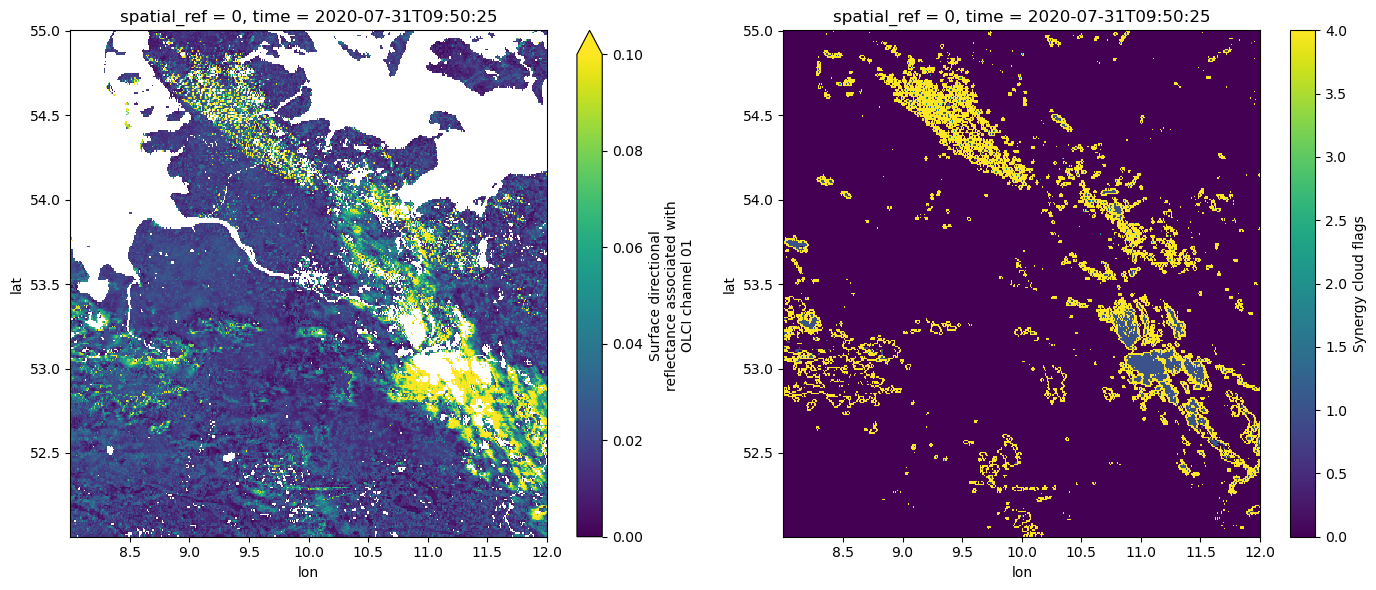

In [9]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.SDR_Oa01[::4, ::4].plot(ax=ax[0], vmax=0.1, vmin=0.)
ds.CLOUD_flags[::4, ::4].plot(ax=ax[1])
plt.tight_layout()

Next, we retrieve ARDC from the Sentinel-3 SLSTR Land Surface Temperature collection (`"sentinel-3-sl-2-lst-ntc"`).

In [10]:
%%time
ds = store.open_data(
    data_id="sentinel-3-sl-2-lst-ntc",
    bbox=[8, 52, 12, 55],
    time_range=["2020-08-01", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
)
ds

CPU times: user 35.3 s, sys: 22.9 s, total: 58.2 s
Wall time: 2min 32s


<xarray.Dataset> Size: 90MB
Dimensions:                      (time: 2, lat: 1336, lon: 1782)
Coordinates:
  * time                         (time) datetime64[s] 16B 2020-08-01T09:40:22...
  * lat                          (lat) float64 11kB 55.0 55.0 ... 52.0 52.0
  * lon                          (lon) float64 14kB 8.001 8.003 ... 12.0 12.0
    spatial_ref                  int64 8B 0
Data variables:
    LST                          (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    bayes_in                     (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    probability_cloud_single_in  (time, lat, lon) int16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    bayes_orphan_in              (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    cloud_in                     (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    confidence_in                (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    pointing_in                  (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    probability_cloud_dual_in    (time, lat, lon) int16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (19)

HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = 'geodetic_in.nc', er

CPU times: user 8.35 s, sys: 3.2 s, total: 11.5 s
Wall time: 15.9 s


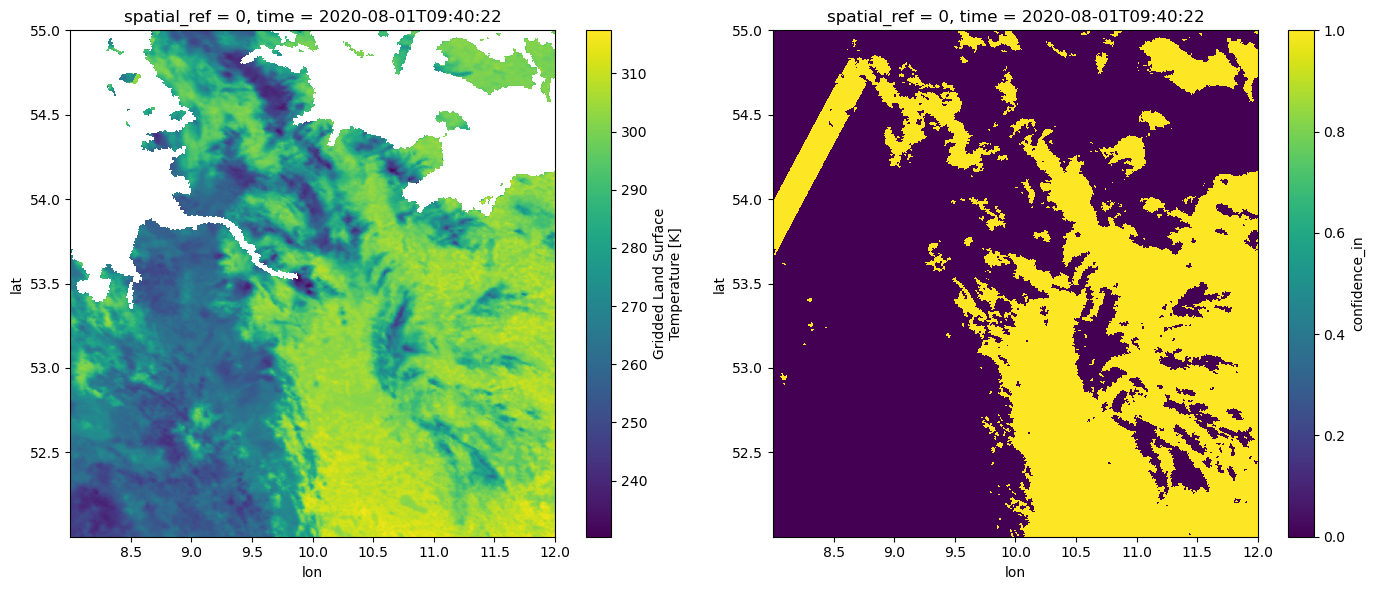

In [11]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.isel(time=0).plot(ax=ax[0])

cloud = (ds.confidence_in & 16384) != 0
no_cloud = ~cloud
no_cloud.isel(time=0).plot(ax=ax[1])

plt.tight_layout()

----
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile. 

In [4]:
%%time
store_params = get_data_store_params_schema("stac-cdse")
store_params

CPU times: user 365 ms, sys: 37 ms, total: 402 ms
Wall time: 401 ms


To initialize the CDSE STAC data store, execute the following cell.

In [5]:
%%time
store = new_data_store("stac-cdse", **credentials)

CPU times: user 14 ms, sys: 2.02 ms, total: 16.1 ms
Wall time: 147 ms


Below, the parameters for the `open_data` method can be viewed.

In [6]:
%%time
open_params = store.get_open_data_params_schema()
open_params

CPU times: user 35 μs, sys: 0 ns, total: 35 μs
Wall time: 37.4 μs


If we specify the data ID, we obtain more precise parameters for opening and accessing that specific dataset.

In [15]:
descriptors = list(
    store.search_data(
        collections=["sentinel-3-syn-2-syn-ntc"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

[{'data_id': 'collections/sentinel-3-syn-2-syn-ntc/items/S3A_SY_2_SYN____20200705T094658_20200705T094958_20200706T235401_0180_060_136_2160_LN2_O_NT_002',
  'data_type': 'dataset',
  'bbox': [-1.51336, 39.5428, 18.4889, 52.4499],
  'time_range': ('2020-07-05T09:46:57.969790Z',
   '2020-07-05T09:49:57.969790Z')},
 {'data_id': 'collections/sentinel-3-syn-2-syn-ntc/items/S3B_SY_2_SYN____20200705T090731_20200705T091031_20200706T223223_0179_040_378_2160_LN2_O_NT_002',
  'data_type': 'dataset',
  'bbox': [8.31522, 39.5562, 28.3241, 52.4659],
  'time_range': ('2020-07-05T09:07:31.314318Z',
   '2020-07-05T09:10:31.314318Z')},
 {'data_id': 'collections/sentinel-3-syn-2-syn-ntc/items/S3A_SY_2_SYN____20200704T101309_20200704T101609_20200705T230603_0179_060_122_2160_LN2_O_NT_002',
  'data_type': 'dataset',
  'bbox': [-8.05807, 39.5416, 11.943, 52.4497],
  'time_range': ('2020-07-04T10:13:08.862747Z',
   '2020-07-04T10:16:08.862747Z')},
 {'data_id': 'collections/sentinel-3-syn-2-syn-ntc/items/S3B_SY

We can now open the data set associated with the data ID. Note that first we do not apply any rectification. Thus the data is shown on the irregular native grid. 

In [16]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

In [17]:
%%time
ds = store.open_data(descriptors[0].data_id, apply_rectification=False, add_error_bands=False)
ds

CPU times: user 1.48 s, sys: 2.91 s, total: 4.39 s
Wall time: 22.8 s


<xarray.Dataset> Size: 5GB
Dimensions:      (y: 4091, x: 4865)
Coordinates:
    lat          (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    lon          (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables: (12/31)
    SDR_S1N      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2O      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3N      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3O      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...           ...
    SDR_Oa21     (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    CLOUD_flags  (y, x) uint8 20MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    OLC_flags    (y, x) uint16 40MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLN_flags    (y, x) uint32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLO_flags    (y, x) uint32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SYN_flags    (y, x) uint16 40MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 2.79 s, sys: 4.81 s, total: 7.6 s
Wall time: 42.2 s


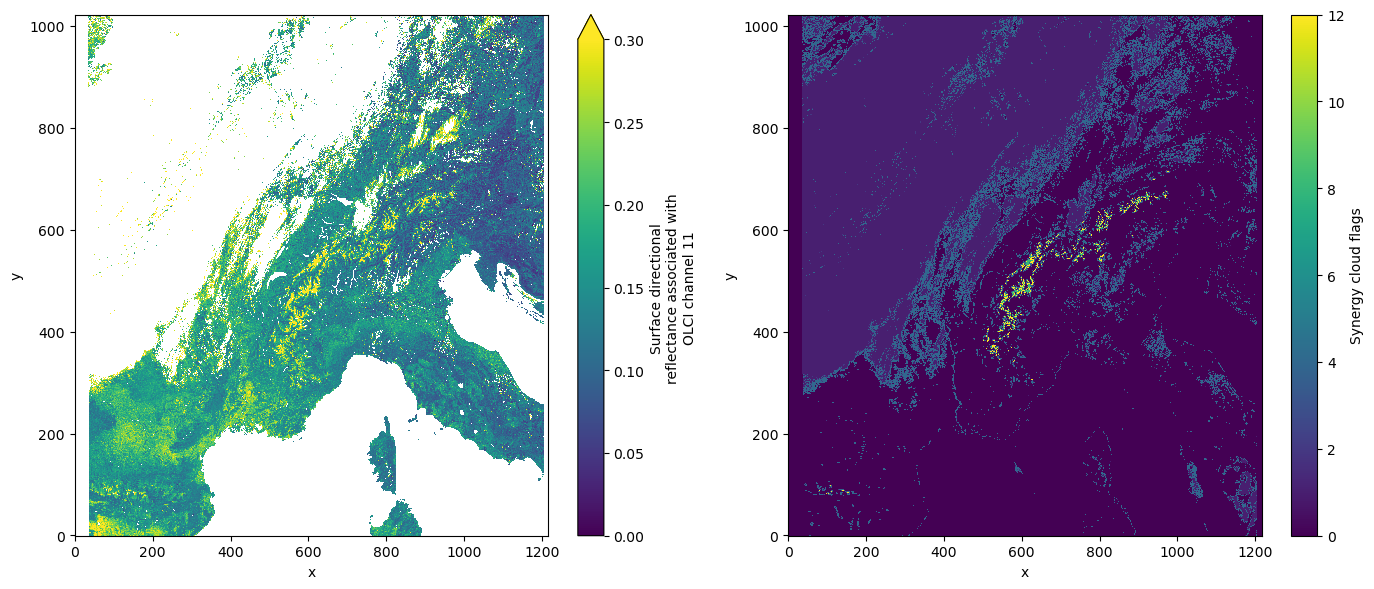

In [18]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.SDR_Oa11[::4, ::4].plot(ax=ax[0], vmax=0.3, vmin=0.)
ds.CLOUD_flags[::4, ::4].plot(ax=ax[1])
plt.tight_layout()

In the next step we show the dataset on a regular grid, where the [xcube's rectification algorithm](https://xcube.readthedocs.io/en/latest/rectify.html) is applied. Note that showing the data on a regular grid is the default. 

In [19]:
%%time
ds = store.open_data(descriptors[0].data_id)
ds

CPU times: user 4.74 s, sys: 6.83 s, total: 11.6 s
Wall time: 50.6 s


<xarray.Dataset> Size: 13GB
Dimensions:       (lon: 5787, lat: 5071)
Coordinates:
  * lon           (lon) float64 46kB -1.513 -1.51 -1.506 ... 18.48 18.48 18.49
  * lat           (lat) float64 41kB 52.45 52.45 52.44 ... 39.55 39.55 39.54
    spatial_ref   int64 8B 0
Data variables: (12/57)
    SDR_S1N       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1N_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...            ...
    SDR_Oa21_err  (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    CLOUD_flags   (lat, lon) uint8 29MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    OLC_flags     (lat, lon) uint16 59MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLN_flags     (lat, lon) uint32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLO_flags     (lat, lon) uint32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SYN_flags     (lat, lon) uint16 59MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 57.9 s, sys: 20.6 s, total: 1min 18s
Wall time: 36.6 s


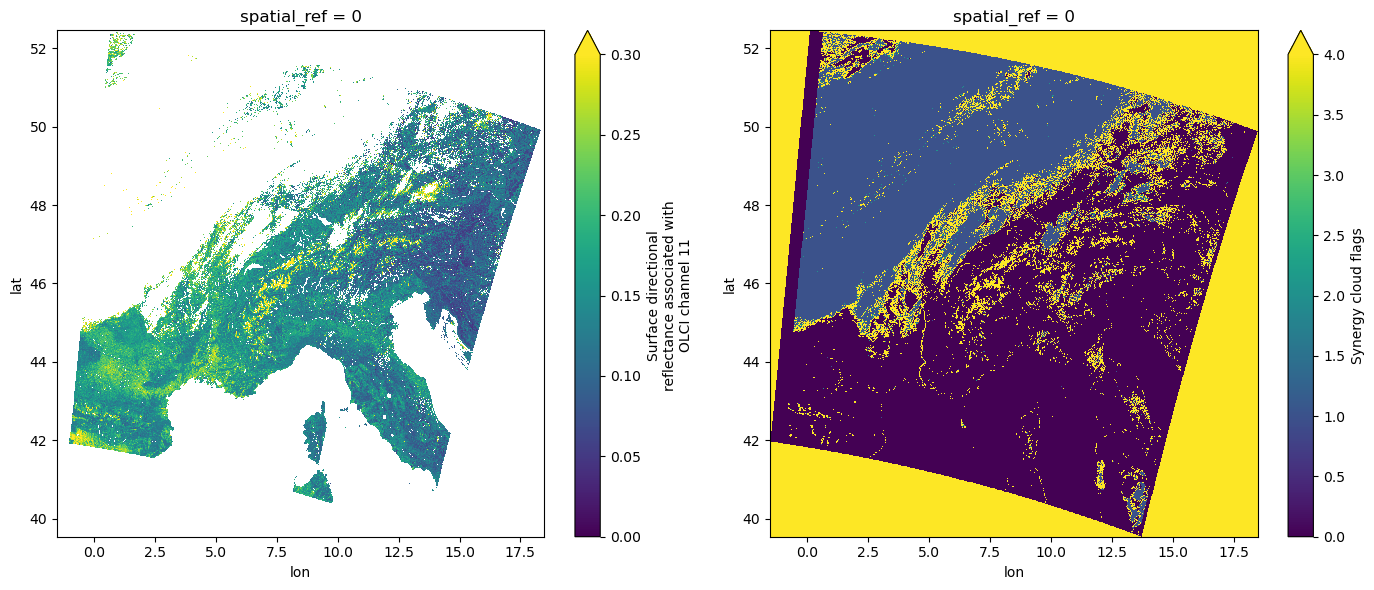

In [20]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.SDR_Oa11[::4, ::4].plot(ax=ax[0], vmax=0.3, vmin=0.)
ds.CLOUD_flags[::4, ::4].plot(ax=ax[1], vmax=4)
plt.tight_layout()

In [7]:
descriptors = list(
    store.search_data(
        collections=["sentinel-3-sl-2-lst-ntc"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

[{'data_id': 'collections/sentinel-3-sl-2-lst-ntc/items/S3A_SL_2_LST____20200705T210953_20200705T211253_20200707T033756_0180_060_143_0720_LN2_O_NT_004',
  'data_type': 'dataset',
  'bbox': [-6.52747, 41.1064, 16.7602, 54.486],
  'time_range': ('2020-07-05T21:09:52.587459Z',
   '2020-07-05T21:12:52.587459Z')},
 {'data_id': 'collections/sentinel-3-sl-2-lst-ntc/items/S3B_SL_2_LST____20200705T203026_20200705T203326_20200707T015740_0179_040_385_0720_LN2_O_NT_004',
  'data_type': 'dataset',
  'bbox': [3.28601, 41.097, 26.5757, 54.4859],
  'time_range': ('2020-07-05T20:30:25.939839Z',
   '2020-07-05T20:33:25.939839Z')},
 {'data_id': 'collections/sentinel-3-sl-2-lst-ntc/items/S3A_SL_2_LST____20200705T094658_20200705T094958_20200706T155921_0179_060_136_2160_LN2_O_NT_004',
  'data_type': 'dataset',
  'bbox': [-1.77345, 39.1027, 20.6113, 52.4606],
  'time_range': ('2020-07-05T09:46:57.969633Z',
   '2020-07-05T09:49:57.969633Z')},
 {'data_id': 'collections/sentinel-3-sl-2-lst-ntc/items/S3B_SL_2_LS

In [8]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

In [10]:
%%time
ds = store.open_data(
    descriptors[0].data_id, 
    apply_rectification=False,
    apply_geo_orthorectification=False,
)
ds

CPU times: user 300 ms, sys: 82.3 ms, total: 382 ms
Wall time: 6.46 s


<xarray.Dataset> Size: 63MB
Dimensions:                      (y: 1200, x: 1500)
Coordinates:
    lat                          (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    lon                          (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    LST                          (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_in                     (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_single_in  (y, x) int16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_orphan_in              (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    cloud_in                     (y, x) uint16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    confidence_in                (y, x) uint16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    pointing_in                  (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_dual_in    (y, x) int16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 676 ms, sys: 251 ms, total: 927 ms
Wall time: 8.83 s


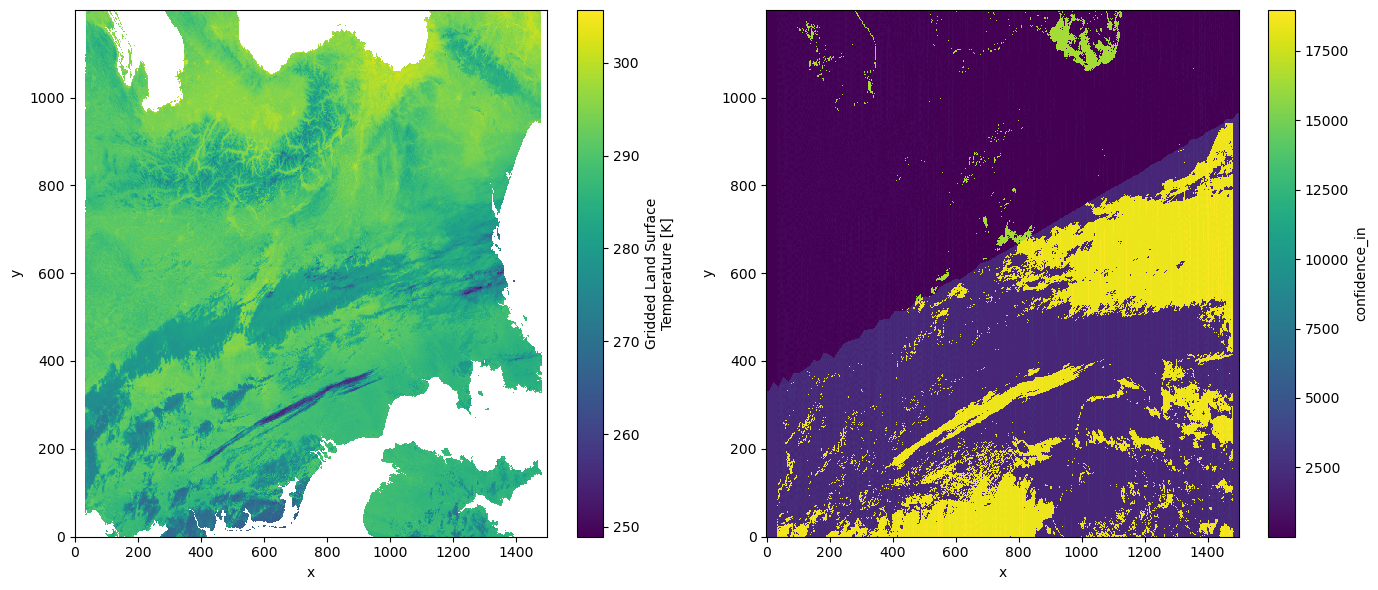

In [11]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.confidence_in.plot(ax=ax[1])
plt.tight_layout()

In [12]:
%%time
ds = store.open_data(descriptors[0].data_id)
ds

CPU times: user 2.7 s, sys: 1.16 s, total: 3.85 s
Wall time: 13 s


<xarray.Dataset> Size: 52MB
Dimensions:                      (lon: 1763, lat: 1553)
Coordinates:
  * lon                          (lon) float64 14kB -6.527 -6.514 ... 16.76
  * lat                          (lat) float64 12kB 54.49 54.48 ... 41.12 41.11
    spatial_ref                  int64 8B 0
Data variables:
    LST                          (lat, lon) float64 22MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_in                     (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_single_in  (lat, lon) int16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_orphan_in              (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    cloud_in                     (lat, lon) uint16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    confidence_in                (lat, lon) uint16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    pointing_in                  (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_dual_in    (lat, lon) int16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 8.92 s, sys: 2.08 s, total: 11 s
Wall time: 4.06 s


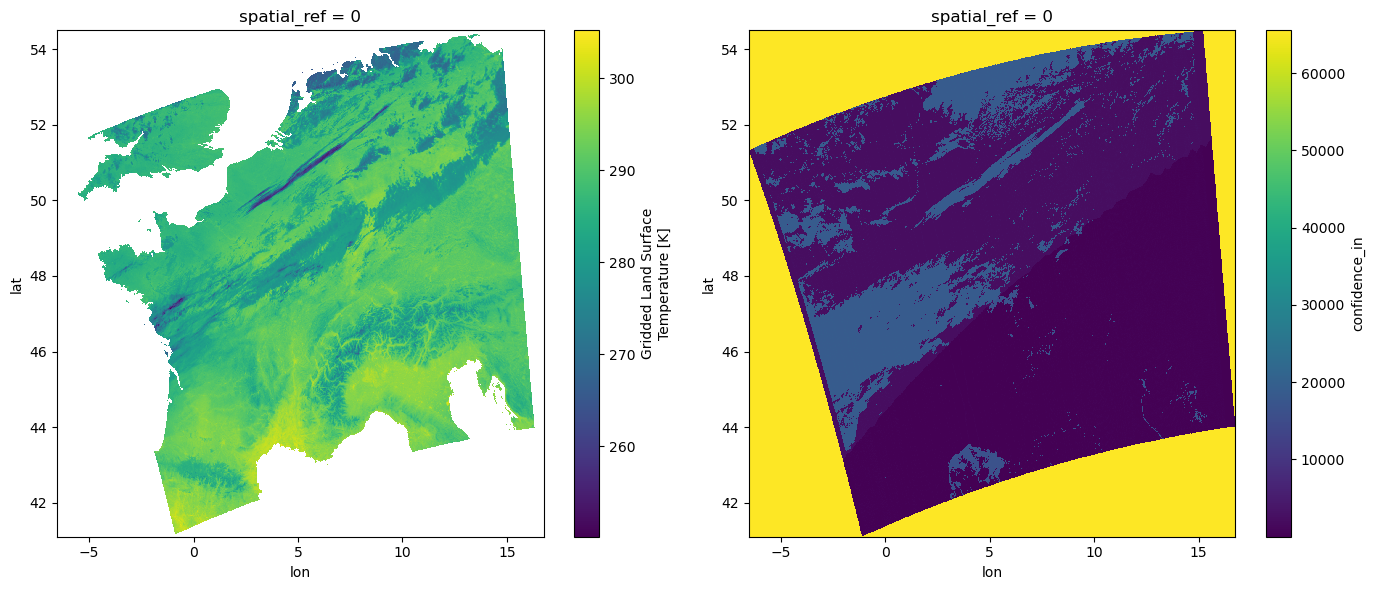

In [13]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.confidence_in.plot(ax=ax[1])
plt.tight_layout()